In [1]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from ultralytics import YOLO
import os
import cv2
import torch
import numpy as np
from collections import defaultdict
import json
from modules import draw_box, load_yolo_labels, save_cropped_boxes, compute_intersection_area

In [113]:
import matplotlib.pyplot as plt

def make_image_with_boxes(
    image,
    tp_data,  # (boxes, classes)
    fp_data,  # (boxes, classes)
    fn_data,  # (boxes, classes)
    output_image_path=None,
    filename=None
):
    
    drawn = image.copy()

    tp_boxes, tp_classes = tp_data
    fp_boxes, fp_classes, _ = fp_data
    fn_boxes, fn_classes = fn_data

    # Draw true positives in green
    for box, cls in zip(tp_boxes, tp_classes):
        draw_box(drawn, box, (0, 255, 0), f"TP: {cls}")

    # Draw false positives in blue
    for box, cls in zip(fp_boxes, fp_classes):
        draw_box(drawn, box, (255, 0, 0), f"FP: {cls}")

    # Draw false negatives in red
    for box, cls in zip(fn_boxes, fn_classes):
        draw_box(drawn, box, (0, 0, 255), f"FN: {cls}")

    if output_image_path:
        cv2.imwrite(os.path.join(output_image_path,os.path.splitext(filename)[0] + "_w_boxes.jpg"), drawn)
    else:
        rgb_image = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_image)
        plt.axis("off")
        plt.show()

In [114]:
#load model
model = YOLO('/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/runs/detect/train2/weights/best.pt')

#set in- & output path
base_input_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split"
base_image_path = os.path.join(base_input_path, "images/val")
base_label_path = os.path.join(base_input_path, "labels/val")

filenames = os.listdir(base_image_path)
filenames.sort()

conf_threshold=0.468

filename = filenames[2]


label_path = os.path.join(base_label_path, os.path.splitext(filename)[0] + ".txt")
label_boxes, label_classes_ids = load_yolo_labels(label_path, image.shape[1], image.shape[0])


non-vectorized

In [115]:
def sliding_window_prediction(image, model, conf_threshold=0.365):
    
    height, width, _ = image.shape
    tile_size = 640
    stride = 420

    num_windows_y = (height - tile_size) // stride + 1
    num_windows_x = (width - tile_size) // stride + 1

    all_boxes = []
    all_scores = []
    all_classes = []

    for i in range(num_windows_y):
        for j in range(num_windows_x):
            y_start = i * stride
            x_start = j * stride
            y_end = y_start + tile_size
            x_end = x_start + tile_size

            window = image[y_start:y_end, x_start:x_end]
            pad_bottom = max(0, y_end - height)
            pad_right = max(0, x_end - width)
            window_padded = cv2.copyMakeBorder(window, 0, pad_bottom, 0, pad_right, cv2.BORDER_CONSTANT, value=(0, 0, 0))

            window_rgb = cv2.cvtColor(window_padded, cv2.COLOR_BGR2RGB)
            window_tensor = torch.tensor(window_rgb / 255.0).permute(2, 0, 1).unsqueeze(0).float().to(model.device)

            results = model(window_tensor, verbose=False, augment=True)
            predictions = results[0].boxes
            valid = predictions.conf > conf_threshold
            predictions = predictions[valid]

            for box, cls, conf in zip(predictions.xyxy.cpu().numpy(), predictions.cls.cpu().numpy(), predictions.conf.cpu().numpy()):
                xmin, ymin, xmax, ymax = box
                # Convert to global coordinates
                xmin += x_start
                xmax += x_start
                ymin += y_start
                ymax += y_start

                all_boxes.append([xmin, ymin, xmax, ymax])
                all_scores.append(conf)
                all_classes.append(int(cls))

    return [all_boxes, all_scores, all_classes]
image = cv2.imread(os.path.join(base_image_path, filename))
boxes, confs, class_ids = sliding_window_prediction(image, model, conf_threshold) #returns lists
print(len(boxes))

116


In [116]:
def nms(boxes, scores, classes, iou_threshold = 0.5):
    
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    classes_tensor = torch.tensor(classes, dtype=torch.int)

    keep_nms = torch.ops.torchvision.nms(boxes_tensor, scores_tensor, iou_threshold)
    boxes_nms = boxes_tensor[keep_nms]
    scores_nms = scores_tensor[keep_nms]
    classes_nms = classes_tensor[keep_nms]

    return [boxes_nms, scores_nms, classes_nms]
boxes, confs, class_ids = nms(boxes, confs, class_ids, iou_threshold=0.4) #transform the lists to tensors
print(len(boxes))

70


In [117]:
def filter_mostly_contained_boxes(boxes, scores, classes, threshold=0.9):

    keep = []
    for i, box_a in enumerate(boxes):
        xa1, ya1, xa2, ya2 = box_a
        area_a = (xa2 - xa1) * (ya2 - ya1)
        if area_a == 0:
            continue

        mostly_contained = False
        for j, box_b in enumerate(boxes):
            if i == j or scores[j] < scores[i]:
                continue
            inter_area = compute_intersection_area(box_a, box_b)
            if area_a > 0 and (inter_area / area_a) >= threshold:
                mostly_contained = True
                break
        if not mostly_contained:
            keep.append(i)

    return [boxes[keep].tolist(), scores[keep].tolist(), classes[keep].tolist()]
boxes, confs, class_ids = filter_mostly_contained_boxes(boxes, confs, class_ids, threshold=0.5)
print(len(boxes))

69


In [118]:
def compute_iou(box1, box2):
    inter_area = compute_intersection_area(box1, box2)
    if inter_area == 0:
        return 0.0
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    iou = inter_area / (box1_area + box2_area - inter_area)
    return iou

def compute_containment_ratio(inner_box, outer_box):
    inter_area = compute_intersection_area(inner_box, outer_box)
    inner_area = (inner_box[2] - inner_box[0]) * (inner_box[3] - inner_box[1])
    return inter_area / inner_area if inner_area > 0 else 0.0


def compare_labels(
    pred_boxes,   # list of predicted boxes: [[xmin, ymin, xmax, ymax], ...]
    pred_classes, # list of predicted classes: [cls_id, ...]
    pred_scores,  # list of confidence scores
    gt_boxes,     # list of ground truth boxes: [[xmin, ymin, xmax, ymax], ...]
    gt_classes,   # list of ground truth classes: [cls_id, ...]
    iou_threshold=0.5,
    containment_threshold=0.9
):
    """
    Compare predicted boxes with ground truth and return TP, FP, FN.
    Only FP confidences are stored.
    """
    matched_gt = set()

    tp_boxes, tp_classes = [], []
    fp_boxes, fp_classes, fp_scores = [], [], []
    fn_boxes, fn_classes = [], []

    for pred_box, pred_cls, pred_score in zip(pred_boxes, pred_classes, pred_scores):
        matched = False
        for i, (gt_box, gt_cls) in enumerate(zip(gt_boxes, gt_classes)):
            if i in matched_gt:
                continue
            if pred_cls == gt_cls:
                iou = compute_iou(pred_box, gt_box)
                containment_pred_in_gt = compute_containment_ratio(pred_box, gt_box)
                containment_gt_in_pred = compute_containment_ratio(gt_box, pred_box)
                if (iou >= iou_threshold or 
                    containment_pred_in_gt >= containment_threshold or 
                    containment_gt_in_pred >= containment_threshold):
                    # True Positive
                    tp_boxes.append(pred_box)
                    tp_classes.append(pred_cls)
                    matched_gt.add(i)
                    matched = True
                    break
        if not matched:
            # False Positive
            fp_boxes.append(pred_box)
            fp_classes.append(pred_cls)
            fp_scores.append(pred_score)

    # False Negatives
    for i, (gt_box, gt_cls) in enumerate(zip(gt_boxes, gt_classes)):
        if i not in matched_gt:
            fn_boxes.append(gt_box)
            fn_classes.append(gt_cls)

    return (tp_boxes, tp_classes), (fp_boxes, fp_classes, fp_scores), (fn_boxes, fn_classes)

tp, fp, fn = compare_labels(pred_boxes=boxes, pred_classes=class_ids, pred_scores=confs,gt_boxes=label_boxes, gt_classes=label_classes_ids, 
                                iou_threshold = 0.5,
                                containment_threshold = 0.5)
print(len(tp[0]), len(fp[0]), len(fn[0]))

59 10 1


In [119]:
tp_slow = tp
fp_slow = fp
fn_slow = fn

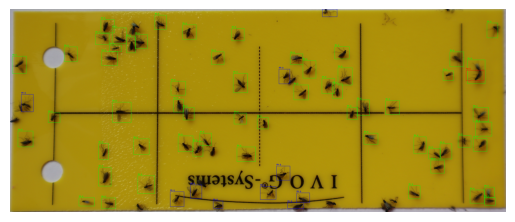

In [120]:
make_image_with_boxes(image, tp[:2], fp, fn)

vectorized?

In [121]:
def sliding_window_prediction(image, model, conf_threshold=0):
    height, width, _ = image.shape
    tile_size = 640
    stride = 440

    num_windows_y = (height - tile_size) // stride + 1
    num_windows_x = (width - tile_size) // stride + 1

    all_boxes, all_scores, all_classes = [], [], []

    for i in range(num_windows_y):
        for j in range(num_windows_x):
            y_start, x_start = i * stride, j * stride
            y_end, x_end = y_start + tile_size, x_start + tile_size

            window = image[y_start:y_end, x_start:x_end]
            pad_bottom, pad_right = max(0, y_end - height), max(0, x_end - width)
            window_padded = cv2.copyMakeBorder(
                window, 0, pad_bottom, 0, pad_right, cv2.BORDER_CONSTANT, value=(0, 0, 0)
            )

            window_rgb = cv2.cvtColor(window_padded, cv2.COLOR_BGR2RGB)
            window_tensor = (
                torch.tensor(window_rgb / 255.0)
                .permute(2, 0, 1)
                .unsqueeze(0)
                .float()
                .to(model.device)
            )

            results = model(window_tensor, verbose=False, augment=True)
            predictions = results[0].boxes

            valid = predictions.conf > conf_threshold
            boxes = predictions.xyxy[valid]
            scores = predictions.conf[valid]
            classes = predictions.cls[valid]
            
            #shifting the coordinates back to full image
            boxes[:, [0, 2]] += x_start
            boxes[:, [1, 3]] += y_start

            all_boxes.append(boxes)
            all_scores.append(scores)
            all_classes.append(classes)

    if len(all_boxes) == 0:
        return torch.zeros((0, 4), device=model.device), torch.zeros((0,), device=model.device), torch.zeros((0,), device=model.device)

    return (
        torch.cat(all_boxes, dim=0),
        torch.cat(all_scores, dim=0),
        torch.cat(all_classes, dim=0),
    )
image = cv2.imread(os.path.join(base_image_path, filename))
boxes, confs, class_ids = sliding_window_prediction(image, model, conf_threshold) #returns lists
print(len(boxes))

77


In [122]:
def nms(boxes, scores, classes, iou_threshold=0.5, device="cuda"):
    if boxes.numel() == 0:
        return boxes, scores, classes
    keep = torch.ops.torchvision.nms(
        boxes.to(device), scores.to(device), iou_threshold
    )
    return boxes[keep], scores[keep], classes[keep]
boxes, confs, class_ids = nms(boxes, confs, class_ids, iou_threshold=0.4) 
print(len(boxes))

52


In [123]:
def filter_mostly_contained_boxes(boxes, scores, classes, threshold=0.5):
    if boxes.numel() == 0:
        return boxes, scores, classes

    boxes = boxes.float()
    scores = scores.float()

    areas = (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (boxes[:, 3] - boxes[:, 1]).clamp(min=0)

    xx1 = torch.max(boxes[:, None, 0], boxes[None, :, 0])
    yy1 = torch.max(boxes[:, None, 1], boxes[None, :, 1])
    xx2 = torch.min(boxes[:, None, 2], boxes[None, :, 2])
    yy2 = torch.min(boxes[:, None, 3], boxes[None, :, 3])

    w = (xx2 - xx1).clamp(min=0)
    h = (yy2 - yy1).clamp(min=0)
    inter = w * h

    containment_ratio = inter / (areas[:, None] + 1e-6)

    # j can suppress i if score[j] >= score[i]
    higher_or_equal_conf_mask = scores[None, :] >= scores[:, None]

    containment_mask = (containment_ratio >= threshold) & higher_or_equal_conf_mask

    # remove self-comparisons
    containment_mask.fill_diagonal_(False)

    mostly_contained = containment_mask.any(dim=1)
    keep = ~mostly_contained

    return boxes[keep], scores[keep], classes[keep]
boxes, confs, class_ids = filter_mostly_contained_boxes(boxes, confs, class_ids, threshold=0.5)    
print(len(boxes))

51


In [124]:
def compare_labels_vectorized(
    pred_boxes,
    pred_classes,
    pred_scores,
    gt_boxes,
    gt_classes,
    tile_size=640,
    iou_threshold=0.5,
    containment_threshold=0.9, convert_to_xyxy = True
):
    """
    Compare YOLO predictions to ground-truth boxes and return TP, FP, FN.

    pred_boxes, gt_boxes: Tensor of shape (N,4) in YOLO format [xc, yc, w, h] normalized (0-1)
    pred_classes, gt_classes: Tensor of shape (N,) integer class IDs
    pred_scores: Tensor of shape (N,) confidence scores
    tile_size: tile size to scale normalized boxes to pixels
    Returns:
        (tp_boxes, tp_classes, tp_scores), (fp_boxes, fp_classes, fp_scores), (fn_boxes, fn_classes)
        All lists with XYXY coordinates in pixels
    """
    device = pred_boxes.device

    if convert_to_xyxy:
        pred_boxes_xyxy = yolo_to_xyxy_tensor(pred_boxes)
        gt_boxes_xyxy   = yolo_to_xyxy_tensor(gt_boxes)
    else:
        pred_boxes_xyxy = pred_boxes
        gt_boxes_xyxy = gt_boxes

    if pred_boxes_xyxy.numel() == 0 and gt_boxes_xyxy.numel() == 0:
        return ([], [], []), ([], [], []), ([], [])

    # Compute areas
    pred_areas = (pred_boxes_xyxy[:, 2] - pred_boxes_xyxy[:, 0]).clamp(min=0) * \
                 (pred_boxes_xyxy[:, 3] - pred_boxes_xyxy[:, 1]).clamp(min=0)
    gt_areas = (gt_boxes_xyxy[:, 2] - gt_boxes_xyxy[:, 0]).clamp(min=0) * \
               (gt_boxes_xyxy[:, 3] - gt_boxes_xyxy[:, 1]).clamp(min=0)

    # Compute intersections
    xx1 = torch.max(pred_boxes_xyxy[:, None, 0], gt_boxes_xyxy[None, :, 0])
    yy1 = torch.max(pred_boxes_xyxy[:, None, 1], gt_boxes_xyxy[None, :, 1])
    xx2 = torch.min(pred_boxes_xyxy[:, None, 2], gt_boxes_xyxy[None, :, 2])
    yy2 = torch.min(pred_boxes_xyxy[:, None, 3], gt_boxes_xyxy[None, :, 3])

    w = (xx2 - xx1).clamp(min=0)
    h = (yy2 - yy1).clamp(min=0)
    inter = w * h

    union = pred_areas[:, None] + gt_areas[None, :] - inter
    iou = inter / (union + 1e-6)

    '''old
    min_area = torch.min(pred_areas[:, None], gt_areas[None, :])
    containment = inter / (min_area + 1e-6)
    '''

    
    containment_pred_in_gt = inter / (pred_areas[:, None] + 1e-6)
    containment_gt_in_pred = inter / (gt_areas[None, :] + 1e-6)
    containment_match = (containment_pred_in_gt >= containment_threshold) | \
                        (containment_gt_in_pred >= containment_threshold)
    

    # Class matching
    class_match = pred_classes[:, None] == gt_classes[None, :]
    match_matrix = class_match & ((iou >= iou_threshold) | containment_match)
    #old
    #match_matrix = class_match & ((iou >= iou_threshold) | (containment >= containment_threshold))

    matched_pred = torch.zeros(pred_boxes.size(0), dtype=torch.bool, device=device)
    matched_gt   = torch.zeros(gt_boxes.size(0), dtype=torch.bool, device=device)

    tp_boxes, tp_classes, tp_scores = [], [], []
    fp_boxes, fp_classes, fp_scores = [], [], []

    # Greedy matching
    for i in range(pred_boxes.size(0)):
        possible = torch.where(match_matrix[i] & ~matched_gt)[0]
        if possible.numel() > 0:
            j = possible[0].item()
            tp_boxes.append(pred_boxes_xyxy[i].cpu().tolist())
            tp_classes.append(int(pred_classes[i].cpu()))
            tp_scores.append(float(pred_scores[i].cpu()))
            matched_gt[j] = True
            matched_pred[i] = True
        else:
            fp_boxes.append(pred_boxes_xyxy[i].cpu().tolist())
            fp_classes.append(int(pred_classes[i].cpu()))
            fp_scores.append(float(pred_scores[i].cpu()))

    fn_boxes = [gt_boxes_xyxy[i].cpu().tolist() for i in range(gt_boxes.size(0)) if not matched_gt[i]]
    fn_classes = [int(gt_classes[i].cpu()) for i in range(gt_classes.size(0)) if not matched_gt[i]]

    return (tp_boxes, tp_classes, tp_scores), (fp_boxes, fp_classes, fp_scores), (fn_boxes, fn_classes)

def yolo_to_xyxy_tensor(boxes, tile_size=640):
    """
    Convert YOLO boxes normalized to a tile into absolute pixel coordinates in the tile.
    Vectorized for torch tensors.

    boxes: Tensor of shape (N, 4) with [xc, yc, w, h] in normalized format (0-1).
    tile_size: size of the tile (default: 640)

    Returns: Tensor of shape (N, 4) with [xmin, ymin, xmax, ymax] in pixel coords.
    """
    boxes = boxes.clone()  # avoid modifying input

    # Scale normalized values by tile size
    boxes[:, 0] = boxes[:, 0] * tile_size  # xc
    boxes[:, 1] = boxes[:, 1] * tile_size  # yc
    boxes[:, 2] = boxes[:, 2] * tile_size  # w
    boxes[:, 3] = boxes[:, 3] * tile_size  # h

    # Compute corners
    x_min = boxes[:, 0] - boxes[:, 2] / 2
    y_min = boxes[:, 1] - boxes[:, 3] / 2
    x_max = boxes[:, 0] + boxes[:, 2] / 2
    y_max = boxes[:, 1] + boxes[:, 3] / 2

    return torch.stack([x_min, y_min, x_max, y_max], dim=1)


label_boxes = torch.tensor(label_boxes).to("cuda")
label_classes_ids = torch.tensor(label_classes_ids).to("cuda")


tp, fp, fn = compare_labels_vectorized(boxes, class_ids, confs, label_boxes, label_classes_ids,
                                               tile_size = 640, iou_threshold=0.5, containment_threshold=0.5, 
                                               convert_to_xyxy=False)
print(len(tp[0]), len(fp[0]), len(fn[0]))

47 4 13


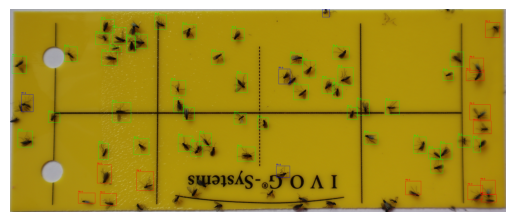

In [125]:
make_image_with_boxes(image, tp[:2], fp, fn)

Compare

In [126]:
print(len(tp[0]), len(fp[0]), len(fn[0]))
print(len(tp_slow[0]), len(fp_slow[0]), len(fn_slow[0]))

47 4 13
59 10 1


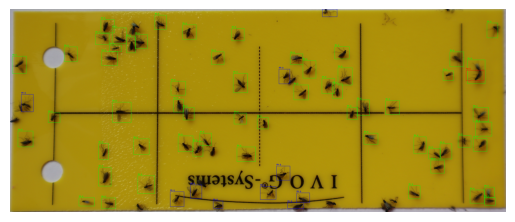

In [127]:
make_image_with_boxes(image, tp_slow[:2], fp_slow, fn_slow)

In [128]:
if not len(tp_slow[0]) == len(tp[0]) or not len(fp_slow[0]) == len(fp[0]) or not len(fn_slow[0]) == len(fn[0]):
    print(filename)

BRAIIM_0270.jpg
